In [67]:
import re
import warnings
import pickle
import html
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import(train_test_split,StratifiedKFold,GridSearchCV,RandomizedSearchCV,cross_validate)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import(AdaBoostClassifier,GradientBoostingClassifier,RandomForestClassifier)
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score,RocCurveDisplay,PrecisionRecallDisplay)
warnings.filterwarnings("ignore")

In [68]:
DATA_PATH="fake_job_postings.csv"
RANDOM_STATE=42

In [69]:
df=pd.read_csv(DATA_PATH)
print(f"Dataset Shape:{df.shape}")
# display(df.head())
display(df.sample(5,random_state=RANDOM_STATE))

Dataset Shape:(17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
4708,4709,Python Engineer,"GB, , London",NaN,NaN,NaN,Stylect is a dynamic startup that helps helps ...,We don’t care where you studied or what your G...,We are negotiable on salary and there is the p...,0,1,0,Full-time,Entry level,Unspecified,Apparel & Fashion,Information Technology,0
11079,11080,Entry Level Sales,"US, OH, Cincinnati",NaN,55000-75000,NaN,General Summary: Achieves maximum sales profit...,NaN,Great Health and DentalFast Advancement Opport...,1,0,0,Full-time,Entry level,High School or equivalent,Financial Services,Sales,0
12357,12358,Agile Project Manager,"US, NY, New York",NaN,NaN,ustwo offers you the opportunity to be yoursel...,"At ustwo™ you get to be yourself, whilst deliv...",Skills• Experience interfacing directly with c...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
14511,14512,Marketing Coordinator,"GB, GBN, London",Business:Marketing,NaN,"We build software for fashion retailers, to he...",About EDITDEDITD runs the world's biggest appa...,Required Skills / Experience:Ability to analys...,NaN,0,1,0,Full-time,NaN,NaN,NaN,Marketing,0
16691,16692,Full-stack Web Engineer,"US, CA, San Francisco",NaN,NaN,Runscope is building tools for developers work...,As a Web Engineer at Runscope you'll be respon...,Extensive front-end web experience (HTML/CSS/J...,Be a part of an experienced team who have work...,0,1,1,Full-time,Mid-Senior level,NaN,NaN,Engineering,0


In [70]:
for column in ["title","industry","function","department"]:
    print("="*80)
    print(column.upper())
    print("="*80)
    display(df[column].dropna().sample(20,random_state=42))
    print()

TITLE


4708                                       Python Engineer
11079                                    Entry Level Sales
12357                                Agile Project Manager
14511                                Marketing Coordinator
16691                              Full-stack Web Engineer
1411                                    BigData Consultant
8515        Customer Care Agent (Night Shift with Spanish)
4989               English Teacher Abroad (Conversational)
361                             Junior System Test Analyst
8250                                     Head of Community
17343                                    Managing Director
5267                  UX Designer - 1871 General Companies
9806                                                Welder
14858             Marketing Intern - Start Somewhere Great
12203                 Videographer / Editor / Photographer
12108                          Market Intelligence Analyst
16999                                  Title/Escrow Clos


INDUSTRY


7130                         Human Resources
11963    Information Technology and Services
6627                       Computer Software
6337                 Staffing and Recruiting
4903                  Hospital & Health Care
17878                         Graphic Design
2320                       Computer Software
17625                     Financial Services
4493                      Financial Services
4154              Logistics and Supply Chain
2147               Marketing and Advertising
15590                      Computer Software
13                           Events Services
1667     Information Technology and Services
9868                    Education Management
8319     Information Technology and Services
5154                      Financial Services
16141                               Internet
5371                  Hospital & Health Care
5219                              Accounting
Name: industry, dtype: object


FUNCTION


477            Customer Service
3411               Data Analyst
14622                Consulting
7814                      Sales
4553                Engineering
10425          Business Analyst
16834          Customer Service
16755                    Design
14877       Accounting/Auditing
8706             Administrative
8448                  Education
14584                    Design
2633                  Marketing
5046     Information Technology
15127    Information Technology
11515               Engineering
15121          Customer Service
6506                  Marketing
6008                      Sales
10077      Business Development
Name: function, dtype: object


DEPARTMENT


14791                           IT
6149                   Development
12660                           IT
15105                  Engineering
14074                   Art Studio
2123                            QA
8128              Product & Design
16748                        Sales
3744                    Ultrasound
3562           Product Development
6129                    Installers
7177                    FRAUD DEPT
8711                   Engineering
7476                    Internship
10647                  Maintenance
12596    Plato's Closet Pleasanton
728                     Operations
15020                    Analytics
16790                Non-Technical
10570                           IT
Name: department, dtype: object

In [71]:
df["industry"].value_counts().head(20)

industry
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
Financial Services                      779
Hospital & Health Care                  497
Consumer Services                       358
Telecommunications                      342
Oil & Energy                            287
Retail                                  223
Real Estate                             175
Accounting                              159
Construction                            158
E-Learning                              139
Management Consulting                   130
Design                                  129
Health, Wellness and Fitness            127
Staffing and Recruiting                 127
Insurance                               123
Name: count, dtype: int64

In [72]:
df["function"].value_counts().head(20)

function
Information Technology    1749
Sales                     1468
Engineering               1348
Customer Service          1229
Marketing                  830
Administrative             630
Design                     340
Health Care Provider       338
Other                      325
Education                  325
Management                 317
Business Development       228
Accounting/Auditing        212
Human Resources            205
Project Management         183
Finance                    172
Consulting                 144
Writing/Editing            132
Art/Creative               132
Production                 116
Name: count, dtype: int64

In [73]:
df["department"].value_counts().head(20)

department
Sales                     551
Engineering               487
Marketing                 401
Operations                270
IT                        225
Development               146
Product                   112
Information Technology     86
Technology                 76
Design                     76
Customer Service           73
Finance                    69
HR                         56
tech                       55
R&D                        54
Creative                   48
Client Services            45
Retail                     45
Product Development        36
Business Development       32
Name: count, dtype: int64

In [74]:
title_before=df["title"].nunique()
title_after=df["title"].str.strip().str.lower().nunique()
print(f"Unique Before : {title_before}")
print(f"Unique After  : {title_after}")
print(f"Reduced By    : {title_before-title_after}")

Unique Before : 11231
Unique After  : 10692
Reduced By    : 539


In [75]:
industry_before=df["industry"].nunique()
industry_after=df["industry"].dropna().str.strip().str.lower().nunique()
print(f"Unique Before : {industry_before}")
print(f"Unique After  : {industry_after}")
print(f"Reduced By    : {industry_before-industry_after}")

Unique Before : 131
Unique After  : 131
Reduced By    : 0


In [76]:
function_before=df["function"].nunique()
function_after=df["function"].dropna().str.strip().str.lower().nunique()
print(f"Unique Before : {function_before}")
print(f"Unique After  : {function_after}")
print(f"Reduced By    : {function_before-function_after}")

Unique Before : 37
Unique After  : 37
Reduced By    : 0


In [77]:
department_before=df["department"].nunique()
department_after=df["department"].dropna().str.strip().str.lower().nunique()
print(f"Unique Before : {department_before}")
print(f"Unique After  : {department_after}")
print(f"Reduced By    : {department_before-department_after}")

Unique Before : 1337
Unique After  : 1224
Reduced By    : 113


## Data Cleaning

In [78]:
df_clean=df.copy()

In [79]:
categorical_columns=["employment_type","required_experience","required_education","industry","function"]
for i in categorical_columns:
    df_clean[i]=df_clean[i].fillna("Unknown")
    df_clean[i]=df_clean[i].str.strip()

In [80]:
text_columns=["title","company_profile","description","requirements","benefits"]
for i in text_columns:
    df_clean[i]=df_clean[i].fillna("")
    df_clean[i]=df_clean[i].str.strip()

In [81]:
df_clean["location"].sample(30,random_state=42)

4708                                         GB, , London
11079                                  US, OH, Cincinnati
12357                                    US, NY, New York
14511                                     GB, GBN, London
16691                               US, CA, San Francisco
1411                                     US, CA, Campbell
8515                                               IE, , 
4989                                       US, MN, Duluth
361                                       GB, CMD, London
8250                                      GB, LND, London
17343                                    US, NY, New York
5267                                      US, IL, Chicago
9806                                      US, TX, Houston
14858                                   US, NV, Las Vegas
12203                               GB, LND, Notting Hill
12108                                              IE, , 
16999                                US, FL, Jacksonville
14556         

In [83]:
display(df_clean[df_clean["location"].str.count(",")!=2]["location"].dropna().head(50))

16                        IL, , Tel Aviv, Israel
42                                            US
69                        US, CA, Menlo Park, CA
98                             US, , Stocton, CA
173                                           US
215           US, CA, Bakersfield, CA / Mt. Poso
219                        SA, 01, Riyadh, Olaya
230                                           US
314                      EG, C, Cairo, Nasr City
343                   GR, I, Neo Iraklio, Athens
368                                           US
392                                           US
440                   GB, UKM, Stockholm, Sweden
502                                           US
540                                           US
695                          GB, , Angel, London
733     US, AL, Birmingham,Montgomery,Atlanta Ga
866                                           AU
895                                           US
962                                           GR
980                 

In [84]:
location_split=df_clean["location"].fillna("").str.split(",",n=2,expand=True)
df_clean["country"]=location_split[0].str.strip()
df_clean["state"]=location_split[1].str.strip()
df_clean["city"]=location_split[2].str.strip()

In [85]:
for i in ["country","state","city"]:
    df_clean[i]=df_clean[i].fillna("Unknown")
    df_clean[i]=df_clean[i].replace("", "Unknown")

In [86]:
df_clean[["country","state","city"]].sample(30,random_state=42)

,country,state,city
4708,GB,Unknown,London
11079,US,OH,Cincinnati
12357,US,NY,New York
14511,GB,GBN,London
16691,US,CA,San Francisco
1411,US,CA,Campbell
8515,IE,Unknown,Unknown
4989,US,MN,Duluth
361,GB,CMD,London
8250,GB,LND,London


In [87]:
department=df_clean["department"].dropna().sort_values().unique()
for i in department:
    print(i)

 
 	Corporate Shared Services
 Lower Level Management
 Marketing 
 Moni Technologies
 R&D
(Consultant)
.NET
.net Development
0
1221
130 - Nutritional Yeast Packaging
1411
20
20131101
30517
3D Art
4
49
5
6 locations in the United States, 3 in Canada and 1 in UK
640 Labs
@ ecgstudio | process improvement specialists
A Techstars Company
ACCOUNTING 
ACCT
ACES
ACT
ADMIN
ADS
AFS12
AFS13
AFS14
AFS16
AFS18
AFSAU
AFSCC
AFSDT
AFSDTV
AFSHAR
AFSHO
AFSHON
AFSHOT
AFSMCA
AFSSA
AGENCY CONFIDENTIAL
ALM Practice
AMG
AMHS
AML
ANDROIDPIT
APP MEDIA
AR
AX 20140308/09 (2)
Aberdeen 
Academic
Account
Account Handling
Account Management
Account team
Account/finance
Accountant
Accounting
Accounting & Finance
Accounting / Finance
Accounting and Finance
Accounting/Finance
Accounting/Payroll
Accounts
Acquisitions and Divesments
Ad Sales
AdOps
AdYapper
Addy
Admin
Admin - Clerical
Admin/Clerical
Administration
Administration 
Administration support
Administrative
Administrative 
Administrative Dept
Administrative Off

In [88]:
display(df_clean["salary_range"].head(20))
print("Missing Values :",df_clean["salary_range"].isna().sum())
print("Unique Values :",df_clean["salary_range"].nunique())

0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
5               NaN
6       20000-28000
7               NaN
8               NaN
9               NaN
10    100000-120000
11              NaN
12              NaN
13              NaN
14              NaN
15    120000-150000
16              NaN
17              NaN
18              NaN
19              NaN
Name: salary_range, dtype: object

Missing Values : 15012
Unique Values : 874


In [89]:
salary_analysis=df_clean.copy()
salary_analysis["has_salary"]=salary_analysis["salary_range"].notna()
display(pd.crosstab(salary_analysis["has_salary"],salary_analysis["fraudulent"],margins=True))

fraudulent,0,1,All
has_salary,,,
False,14369,643,15012
True,2645,223,2868
All,17014,866,17880


In [90]:
display(pd.crosstab(salary_analysis["has_salary"],salary_analysis["fraudulent"],normalize="columns").round(4)*100)

fraudulent,0,1
has_salary,,
False,84.45,74.25
True,15.55,25.75


In [91]:
department_analysis=df_clean.copy()
department_analysis["has_department"]=department_analysis["department"].notna()
display(pd.crosstab(department_analysis["has_department"],department_analysis["fraudulent"],margins=True))

fraudulent,0,1,All
has_department,,,
False,11016,531,11547
True,5998,335,6333
All,17014,866,17880


In [92]:
display(pd.crosstab(department_analysis["has_department"],department_analysis["fraudulent"],normalize="columns").round(4)*100)

fraudulent,0,1
has_department,,
False,64.75,61.32
True,35.25,38.68


## Feature Engineering

In [93]:
df_clean["has_salary"]=df_clean["salary_range"].notna().astype(int)

In [94]:
df_clean["has_company_profile"]=(df_clean["company_profile"]!="").astype(int)

In [95]:
df_clean["has_requirements"]=(df_clean["requirements"]!="").astype(int)

In [96]:
df_clean["description_length"]=df_clean["description"].str.len()

In [97]:
df_clean["requirements_length"]=df_clean["requirements"].str.len()

In [98]:
df_clean["company_profile_length"]=df_clean["company_profile"].str.len()

In [99]:
df_clean["benefits_length"]=df_clean["benefits"].str.len()

In [100]:
binary_features=["has_salary","has_company_profile","has_requirements"]
for i in binary_features:
    print("="*60)
    print(i)
    print("="*60)
    display(pd.crosstab(df_clean[i],df_clean["fraudulent"],normalize="columns").round(4)*100)
    print()

has_salary


fraudulent,0,1
has_salary,,
0,84.45,74.25
1,15.55,25.75



has_company_profile


fraudulent,0,1
has_company_profile,,
0,15.99,67.78
1,84.01,32.22



has_requirements


fraudulent,0,1
has_requirements,,
0,14.95,17.78
1,85.05,82.22


In [101]:
suspicious_words=["telegram",
    "whatsapp",
    "registration fee",
    "processing fee",
    "security deposit",
    "payment required",
    "wire transfer",
    "bank account",
    "investment required",
    "guaranteed income",
    "apply immediately",
    "limited seats",
    "immediate joining",
    "no experience required"]

In [102]:
def suspicious_word_count(text):
    text=text.lower()
    count=0
    for word in suspicious_words:
        count+=len(re.findall(r"\b"+re.escape(word)+r"\b",text))
    return count

In [103]:
df_clean["combined_text"]=(df_clean["title"]+" "+df_clean["company_profile"]+" "+df_clean["description"]+" "+df_clean["requirements"]+" "+df_clean["benefits"])

In [104]:
df_clean["suspicious_word_count"]=df_clean["combined_text"].apply(suspicious_word_count)

In [105]:
display(pd.crosstab(df_clean["suspicious_word_count"]>0,df_clean["fraudulent"],normalize="columns").round(4)*100)

fraudulent,0,1
suspicious_word_count,,
False,99.01,98.04
True,0.99,1.96


## Text Preprocessing

In [106]:
def clean_text(text):
    text=html.unescape(text)
    text=re.sub(r"http\S*#URL_[^\s#]+#"," ",text)
    text=re.sub(r"#URL_[^\s#]+#"," ",text)
    text=re.sub(r"#EMAIL_[^\s#]+#"," ",text)
    text=re.sub(r"#PHONE_[^\s#]+#"," ",text)
    text=text.lower()
    text=re.sub(r"[‘’´`]", "",text)
    text=re.sub(rf"[{re.escape(string.punctuation)}]"," ",text)
    text=re.sub(r"\b[a-z]\b"," ",text)
    text=re.sub(r"\s+"," ",text).strip()
    return text

In [107]:
df_clean["cleaned_text"]=df_clean["combined_text"].apply(clean_text)

In [108]:
df_clean["cleaned_text"].str.split().str.len().describe()

count    17880.000000
mean       379.631879
std        211.321205
min          2.000000
25%        229.000000
50%        354.000000
75%        497.000000
max       2122.000000
Name: cleaned_text, dtype: float64

## Train-Test Split

In [109]:
x=df_clean.drop(columns=["fraudulent"])
y=df_clean["fraudulent"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [110]:
text_features=["cleaned_text"]
categorical_features=["employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function",
    "country",
    "state",
    "city"]

binary_features=["telecommuting",
    "has_company_logo",
    "has_questions",
    "has_salary",
    "has_company_profile",
    "has_requirements"]

numerical_features=["description_length",
    "requirements_length",
    "company_profile_length",
    "benefits_length",
    "suspicious_word_count"]

## Data Preprocessing Pipeline

In [111]:
tfidf=TfidfVectorizer(max_features=5000,ngram_range=(1,2),min_df=2,max_df=0.95,stop_words="english")

In [112]:
encoder=OneHotEncoder(handle_unknown="ignore")

In [113]:
preprocessor=ColumnTransformer(transformers=[("text",tfidf,"cleaned_text"),("categorical",encoder,categorical_features),("numerical","passthrough",numerical_features),("binary","passthrough",binary_features)])

In [114]:
x_train_processed=preprocessor.fit_transform(x_train)
x_test_processed=preprocessor.transform(x_test)
print("Training Shape :",x_train_processed.shape)
print("Testing Shape  :",x_test_processed.shape)

Training Shape : (14304, 7627)
Testing Shape  : (3576, 7627)


In [115]:
print("TF-IDF Features :",len(preprocessor.named_transformers_["text"].get_feature_names_out()))
print("Categorical Features :",len(preprocessor.named_transformers_["categorical"].get_feature_names_out()))
print("Numerical Features :",len(numerical_features))
print("Binary Features :",len(binary_features))

TF-IDF Features : 5000
Categorical Features : 2616
Numerical Features : 5
Binary Features : 6


In [116]:
results=[]
def evaluate_model(model,name):
    model.fit(x_train_processed,y_train)
    y_pred=model.predict(x_test_processed)
    if hasattr(model,"predict_proba"):
        y_score=model.predict_proba(x_test_processed)[:,1]
    elif hasattr(model,"decision_function"):
        y_score=model.decision_function(x_test_processed)
    else:
        y_score=None
    results.append({"Model":name,
        "Accuracy":accuracy_score(y_test,y_pred),
        "Precision":precision_score(y_test,y_pred),
        "Recall":recall_score(y_test,y_pred),
        "F1 Score":f1_score(y_test,y_pred),
        "ROC AUC":roc_auc_score(y_test,y_score) if y_score is not None else None})

## Model Training

In [117]:
results=[]
models={
    "Logistic Regression":LogisticRegression(
        solver="saga",
        max_iter=3000,
        random_state=42,
        n_jobs=-1
    ),

    "Linear SVM":LinearSVC(
        random_state=42
    ),

    "Multinomial Naive Bayes":MultinomialNB(),

    "Random Forest":RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost":XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM":LGBMClassifier(
        random_state=42,
        verbose=-1
    ),

    "CatBoost":CatBoostClassifier(
        random_state=42,
        verbose=0
    )
}

for name,model in models.items():
    print(f"Training {name}...")
    evaluate_model(model,name)

print("Training Completed.")

Training Logistic Regression...
Training Linear SVM...
Training Multinomial Naive Bayes...
Training Random Forest...
Training XGBoost...
Training LightGBM...
Training CatBoost...
Training Completed.


In [118]:
results_df=pd.DataFrame(results)
results_df=results_df.sort_values(by="F1 Score",ascending=False).reset_index(drop=True)
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LightGBM,0.9899,0.9790,0.8092,0.8861,0.9953
1,CatBoost,0.9860,0.9695,0.7341,0.8355,0.9900
2,Linear SVM,0.9849,0.9612,0.7168,0.8212,0.9852
3,XGBoost,0.9843,0.9270,0.7341,0.8194,0.9933
4,Random Forest,0.9801,1.0000,0.5896,0.7418,0.9942
5,Multinomial Naive Bayes,0.6381,0.0876,0.6879,0.1554,0.6924
6,Logistic Regression,0.9516,0.0000,0.0000,0.0000,0.6977


## Cross Validation

In [119]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [120]:
cv_models={"LightGBM":LGBMClassifier(random_state=42,verbose=-1),"Linear SVM":LinearSVC(random_state=42)}

In [121]:
cv_results=[]
scoring=["accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"]

for name,model in cv_models.items():
    pipeline=Pipeline([("preprocessor",preprocessor),("classifier",model)])

    scores=cross_validate(pipeline,x,y,cv=cv,scoring=scoring,n_jobs=1)

    cv_results.append({"Model":name,
        "Accuracy Mean":scores["test_accuracy"].mean(),
        "Accuracy Std":scores["test_accuracy"].std(),
        "Precision Mean":scores["test_precision"].mean(),
        "Precision Std":scores["test_precision"].std(),
        "Recall Mean":scores["test_recall"].mean(),
        "Recall Std":scores["test_recall"].std(),
        "F1 Mean":scores["test_f1"].mean(),
        "F1 Std":scores["test_f1"].std(),
        "ROC AUC Mean":scores["test_roc_auc"].mean(),
        "ROC AUC Std":scores["test_roc_auc"].std()})

In [122]:
cv_results_df=pd.DataFrame(cv_results)
cv_results_df=cv_results_df.sort_values(by="F1 Mean",ascending=False).reset_index(drop=True)
display(cv_results_df.round(4))

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC AUC Mean,ROC AUC Std
0,LightGBM,0.9867,0.0013,0.9607,0.0109,0.7564,0.0282,0.8460,0.0166,0.9923,0.0022
1,Linear SVM,0.9836,0.0019,0.9297,0.0209,0.7160,0.0318,0.8086,0.0247,0.9852,0.0032


In [ ]:
############################# final_pipeline=Pipeline([("preprocessor",preprocessor),("classifier",LGBMClassifier(random_state=42,verbose=-1,n_jobs=1))])

In [147]:
negative=(y_train==0).sum()
positive=(y_train==1).sum()

scale_weight=negative/positive

print(scale_weight)

19.64069264069264


In [ ]:
final_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",
     LGBMClassifier(
         random_state=42,
         verbose=-1,
         scale_pos_weight=scale_weight
     ))
])


In [131]:
param_distributions={
    "classifier__n_estimators": randint(100,600),
    "classifier__learning_rate": uniform(0.01,0.19),
    "classifier__num_leaves": randint(20,150),
    "classifier__max_depth":[-1,5,10,15,20,30],
    "classifier__min_child_samples": randint(10,100),
    "classifier__subsample": uniform(0.6,0.4),
    "classifier__colsample_bytree": uniform(0.6,0.4),
    "classifier__reg_alpha": uniform(0,5),
    "classifier__reg_lambda": uniform(0,5)
}

## Hyperparameter Tuning

In [149]:
random_search=RandomizedSearchCV(
    estimator=final_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=2,
    verbose=2
)

random_search.fit(x_train,y_train)

best_model=random_search.best_estimator_

y_pred=best_model.predict(x_test)
y_prob=best_model.predict_proba(x_test)[:,1]

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [150]:
print("Best Parameters:")
print(random_search.best_params_)
print()
print("Best Cross Validation F1 Score:")
print(round(random_search.best_score_,4))

Best Parameters:
{'classifier__colsample_bytree': np.float64(0.6390688456025535), 'classifier__learning_rate': np.float64(0.14000427503730983), 'classifier__max_depth': 15, 'classifier__min_child_samples': 80, 'classifier__n_estimators': 527, 'classifier__num_leaves': 27, 'classifier__reg_alpha': np.float64(0.17194260557609198), 'classifier__reg_lambda': np.float64(4.546602010393911), 'classifier__subsample': np.float64(0.7035119926400067)}

Best Cross Validation F1 Score:
0.8259


In [144]:
best_model=random_search.best_estimator_
y_pred=best_model.predict(x_test)
y_prob=best_model.predict_proba(x_test)[:,1]

In [151]:
final_results=pd.DataFrame({"Metric":["Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"],
    "Value":[accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred),
        roc_auc_score(y_test,y_prob)]})
display(final_results.round(4))

,Metric,Value
0,Accuracy,0.9894
1,Precision,0.9412
2,Recall,0.8324
3,F1 Score,0.8834
4,ROC AUC,0.9923


In [152]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))
print("ROC AUC  :",roc_auc_score(y_test,y_prob))

Accuracy : 0.9893736017897091
Precision: 0.9411764705882353
Recall   : 0.8323699421965318
F1 Score : 0.8834355828220859
ROC AUC  : 0.9923376007908697


## Final Model Evaluation

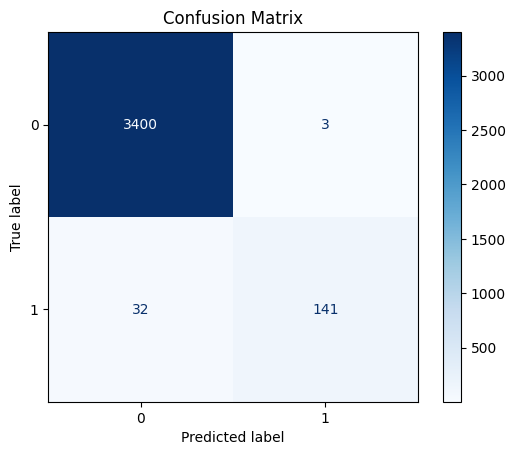

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap="Blues",values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.98      0.82      0.89       173

    accuracy                           0.99      3576
   macro avg       0.98      0.91      0.94      3576
weighted avg       0.99      0.99      0.99      3576



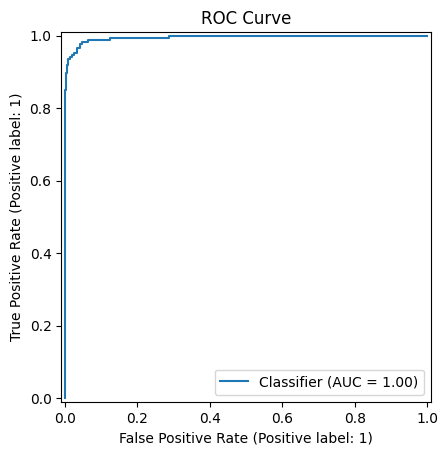

In [ ]:
RocCurveDisplay.from_predictions(y_test,y_prob)
plt.title("ROC Curve")
plt.show()

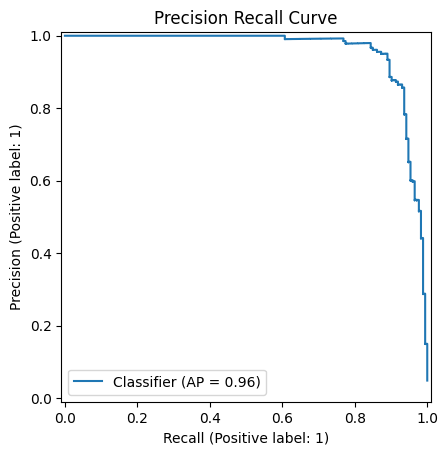

In [ ]:
PrecisionRecallDisplay.from_predictions(y_test,y_prob)
plt.title("Precision Recall Curve")
plt.show()

In [ ]:
pickle.dump(best_model,open("fjd_model.pkl","wb"))
print("Model saved successfully.")

Model saved successfully.


In [ ]:
# model=pickle.load(open("fjd_model.pkl","rb"))
# print("Model loaded successfully.")
# sample_prediction=model.predict(x_test.iloc[:5])
# print("Sample Prediction :",sample_prediction)

Model loaded successfully.
Sample Prediction : [0 0 0 0 0]


In [ ]:
print("="*60)
print("FINAL MODEL SUMMARY")
print("="*60)
print(f"Model                : LightGBM")
print(f"Accuracy             : {accuracy_score(y_test,y_pred):.4f}")
print(f"Precision            : {precision_score(y_test,y_pred):.4f}")
print(f"Recall               : {recall_score(y_test,y_pred):.4f}")
print(f"F1 Score             : {f1_score(y_test,y_pred):.4f}")
print(f"ROC AUC              : {roc_auc_score(y_test,y_prob):.4f}")

print()

FINAL MODEL SUMMARY
Model                : LightGBM
Accuracy             : 0.9902
Precision            : 0.9792
Recall               : 0.8150
F1 Score             : 0.8896
ROC AUC              : 0.9953



In [ ]:
print("="*60)
print("BEST PARAMETERS")
print("="*60)
for key,value in random_search.best_params_.items():
    print(f"{key} : {value}")

BEST PARAMETERS
classifier__num_leaves : 31
classifier__n_estimators : 200
classifier__max_depth : -1
classifier__learning_rate : 0.05


In [ ]:
# best_model=pickle.load(open("fjd_model.pkl","rb"))

              precision    recall  f1-score   support

           0     0.9907    0.9991    0.9949      3403
           1     0.9792    0.8150    0.8896       173

    accuracy                         0.9902      3576
   macro avg     0.9849    0.9071    0.9422      3576
weighted avg     0.9901    0.9902    0.9898      3576



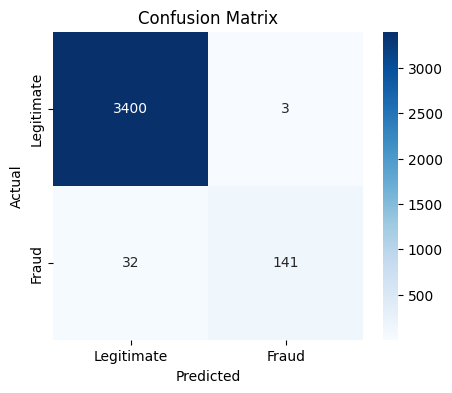

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = best_model.predict(x_test)

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))

Precision : 0.9791666666666666
Recall    : 0.815028901734104
F1 Score  : 0.889589905362776


In [ ]:
from collections import Counter

print(Counter(y_train))
print(Counter(y_test))

Counter({0: 13611, 1: 693})
Counter({0: 3403, 1: 173})


In [ ]:
false_negative_index = y_test[(y_test == 1) & (y_pred == 0)].index

false_negative_df = df_clean.loc[
    false_negative_index,
    [
        "title",
        "description",
        "requirements",
        "company_profile",
        "industry",
        "employment_type",
        "fraudulent"
    ]
]

print("False Negatives:", len(false_negative_df))

display(false_negative_df.head(20))

False Negatives: 32


,title,description,requirements,company_profile,industry,employment_type,fraudulent
17648,Vemma Brand Partner,Looking for motivated and hard working individ...,Motivated and willing to work with a team!,,Marketing and Advertising,Full-time,1
12104,Production Manager Heavy Duty Diesel 2022,2022Job Title: Production Manager Heavy Duty D...,Bottom Line Requirements:1. Bachelor's degree...,,Unknown,Full-time,1
17549,Sales manager,Collaborates with [Insert title] in establishi...,• Performs sales activities on major accounts ...,,Accounting,Full-time,1
17619,JOB VACANCY IN ST.ERMIN'S HOTEL LONDON,"St. Ermin's Hotel2 Caxton Street Westminster, ...",CONFERENCE &amp; BANQUETING OPERATIONS MANAGER...,,Hospitality,Full-time,1
4593,Code Compliance Officer,: Responsible for the enforcement of the build...,Work requires knowledge of a specific vocation...,The Accion story began more than 100 years ag...,Public Safety,Full-time,1
17598,Real Estate & Insurance Professionals,"Real Estate, Mortgage &amp; Insurance Professi...",Real Estate Broker we would like You to consid...,Elite Realty Services was formed in 2004 by it...,Unknown,Unknown,1
10407,Hotel Workers Needed,"Ref: HOVER-ORC-B55UK07-14Hotel Verta, a luxury...",Relocation EligibleDegree/Certification holder...,"Hotel Verta, a luxury boutique hotel located o...",Hospitality,Full-time,1
17808,"vacancies,nannies,cooks,drivers and housekeepe...",We are hiring home / domestic #URL_a611accdf5e...,We are hiring home / domestic #URL_a611accdf5e...,,Hospital & Health Care,Full-time,1
17556,Customer Service Representative to Enroll Peop...,Normal 0 false false false ...,,Join the Your Phone Connect team and earn mone...,Telecommunications,Contract,1
4599,Mortgage Customer Service Coordinator (Call Ce...,Answer approximately 75 incoming customer call...,"Basic Qualifications - A Bachelor’s degree, WI...",The Accion story began more than 100 years ag...,Management Consulting,Full-time,1


In [ ]:
false_positive_index = y_test[(y_test == 0) & (y_pred == 1)].index

false_positive_df = df_clean.loc[
    false_positive_index,
    [
        "title",
        "description",
        "requirements",
        "company_profile",
        "industry",
        "employment_type",
        "fraudulent"
    ]
]

print("False Positives:", len(false_positive_df))

display(false_positive_df)

False Positives: 3


,title,description,requirements,company_profile,industry,employment_type,fraudulent
7237,Sales Consultant,I am looking for a few women to join my team. ...,"Sylish, likes fashion, is outgoing, and wants ...",,Unknown,Unknown,0
6784,Receptionist,Quest College is seeking an individual to join...,,,Education Management,Full-time,0
16970,Customer Service - Work From Home,Do you have 1+ year of customer service/call c...,Job Requirements/Qualifications:* 1+ year of C...,,Consumer Services,Contract,0


In [ ]:
false_negative_probs = best_model.predict_proba(x_test)[:, 1]

fn_probs = false_negative_probs[(y_test == 1) & (y_pred == 0)]

print(fn_probs[:20])

[0.01693651 0.29002537 0.23357622 0.49307256 0.39211844 0.01208807
 0.02177529 0.13478966 0.06644948 0.32204257 0.07280216 0.48501246
 0.04005647 0.00545815 0.27123544 0.06303297 0.0299766  0.15378492
 0.09882925 0.16057897]


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds=[0.25,0.30,0.35,0.40,0.45,0.50]

probs=best_model.predict_proba(x_test)[:,1]

for t in thresholds:

    pred=(probs>=t).astype(int)

    print("="*40)
    print("Threshold:",t)
    print("Precision:",round(precision_score(y_test,pred),4))
    print("Recall:",round(recall_score(y_test,pred),4))
    print("F1:",round(f1_score(y_test,pred),4))

Threshold: 0.25
Precision: 0.9551
Recall: 0.8613
F1: 0.9058
Threshold: 0.3
Precision: 0.9608
Recall: 0.8497
F1: 0.9018
Threshold: 0.35
Precision: 0.9733
Recall: 0.8439
F1: 0.904
Threshold: 0.4
Precision: 0.9797
Recall: 0.8382
F1: 0.9034
Threshold: 0.45
Precision: 0.9796
Recall: 0.8324
F1: 0.9
Threshold: 0.5
Precision: 0.9792
Recall: 0.815
F1: 0.8896


# Conclusion

The optimized LightGBM model achieved strong performance in detecting fraudulent job postings. The complete preprocessing pipeline and trained model were saved for deployment, enabling real-time fraud prediction through a Streamlit web application.

**Final Model**

- Accuracy: 99.02%
- Precision: 97.92%
- Recall: 81.50%
- F1 Score: 88.96%
- ROC-AUC: 99.53%